In [2]:
#Evidence 2. Problem Situation

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

palette = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#8C8C00', '#7F3C8D', '#000000']
ticker_order =['JNJ', 'AMZN', 'SPX', 'UBER', 'ORCL', 'CAT', 'NFLX', 'V', 'DIS', 'KO']
portfolio_tickers = [t for t in ticker_order if t != 'SPX']
color_map = dict(zip(ticker_order, palette))

RF_ANNUAL = 0.040
PORTFOLIO_VALUE = 1_000_000
PER_STOCK_VALUE = PORTFOLIO_VALUE / len(portfolio_tickers)

fondo = pd.read_csv('fondo_clean.csv', parse_dates=['Date'])
wide = fondo.pivot_table(index='Date', columns='Ticker', values='Daily_Return').sort_index()
close_wide = fondo.pivot_table(index='Date', columns='Ticker', values='Close').sort_index()
port_ret = wide[portfolio_tickers].mean(axis=1)
spx_ret = wide['SPX']
fondo.shape

(12560, 9)

##1. Determination of the Investment Universe

We keep all the stocks from the deliverable 1. Since they showed a defensive spread of betas and no name with data quality problems, so there's no reason to drop any of them. JNJ, AMZN, UBER, ORCL, CAT, NFLX, V, DIS, KO. And the S&P 500 is kept as the benchmark we compare the portfolio against.

##2. Algorithms for Calculating Risk Metrics

Volatility, beta, sharpe ratio, and 1 day value at risk via monte carlo simulation.

In [4]:
rows =[]
for t in ticker_order:
    r = wide[t].dropna()
    ann_vol = r.std() * np.sqrt(252)
    ann_ret = r.mean() * 252
    if t == 'SPX':
        beta = 1.00
    else:
        joined = pd.concat([r, spx_ret], axis=1, keys=['stock', 'mkt']).dropna()
        beta=np.cov(joined['stock'], joined['mkt'])[0,1] / np.var(joined['mkt'])
    sharpe = (ann_ret - RF_ANNUAL) / ann_vol
    rows.append({'Ticker': t, 'Ann_Return': ann_ret, 'Ann_Volatility': ann_vol, 'Beta': beta, 'Sharpe': sharpe})

port_ann_vol = port_ret.std() * np.sqrt(252)
port_ann_ret = port_ret.mean() * 252
port_joined = pd.concat([port_ret, spx_ret], axis=1, keys=['p', 'mkt']).dropna()
port_beta = np.cov(port_joined['p'], port_joined['mkt'])[0,1] / np.var(port_joined['mkt'])
port_sharpe = (port_ann_ret - RF_ANNUAL) / port_ann_vol
rows.append({'Ticker': 'Portfolio', 'Ann_Return': port_ann_ret, 'Ann_Volatility': port_ann_vol, 'Beta': port_beta, 'Sharpe': port_sharpe})

risk_metrics = pd.DataFrame(rows).round(4)
risk_metrics

,Ticker,Ann_Return,Ann_Volatility,Beta,Sharpe
0,JNJ,0.1087,0.1764,0.1601,0.3897
1,AMZN,0.1449,0.3646,1.5099,0.2878
2,SPX,0.1231,0.1704,1.0000,0.4877
3,UBER,0.2191,0.4526,1.3566,0.3956
4,ORCL,0.1963,0.4370,1.2385,0.3576
5,CAT,0.3285,0.3180,1.0651,0.9071
6,NFLX,0.1509,0.4370,1.2209,0.2539
7,V,0.1265,0.2296,0.8093,0.3767
8,DIS,-0.0659,0.2962,1.0132,-0.3574
9,KO,0.1069,0.1675,0.2595,0.3992


CAT has the best risk adjusted return of any single stock, and the portfolio's sharpe beats every individual stock excet CAT, diversification is doing its job. DIS is the only name with a negative sharpe ratio.

In [5]:
rng = np.random.default_rng(42)
N_SIM = 100_000
var_rows = []
sim_cache = {}
for t in portfolio_tickers + ['PORTFOLIO']:
    if t  == 'PORTFOLIO':
        mu, sigma, notional = port_ret.mean(), port_ret.std(), PORTFOLIO_VALUE
    else:
        r = wide[t].dropna()
        mu, sigma, notional = r.mean(), r.std(), PER_STOCK_VALUE
    sims = rng.normal(mu, sigma, N_SIM)
    sim_cache[t] = sims
    var95_pct = -np.percentile(sims, 5)
    var99_pct = -np.percentile(sims, 1)
    var_rows.append({'Ticker': t, 'Notional_USD': notional, 'VaR_95_pct': var95_pct, 'VaR_95_pct': var95_pct * notional, 'VaR_99_pct': var99_pct, 'VaR_99_pct': var99_pct * notional})

var_table = pd.DataFrame(var_rows).round(4)
var_table

,Ticker,Notional_USD,VaR_95_pct,VaR_99_pct
0,JNJ,111111.1111,1999.0824,2844.8336
1,AMZN,111111.1111,4134.1843,5838.1735
2,UBER,111111.1111,5086.4446,7238.9652
3,ORCL,111111.1111,4972.4086,7035.3824
4,CAT,111111.1111,3538.3122,5045.6123
5,NFLX,111111.1111,4986.5123,7139.6786
6,V,111111.1111,2597.9343,3709.9350
7,DIS,111111.1111,3439.0256,4838.5587
8,KO,111111.1111,1885.7923,2693.3784
9,PORTFOLIO,1000000.0000,18813.1485,26849.1185


On a $1,000,000 portfolio, the model says: on a normal day, we don't expect to lose more than 1.9% 95% of the time, or more than 2.7% 99% of the time. UBER, ORCL, and NFLX carry the highest individual VAR, consistent with their high beta and volatility from the first delivery.

##3. Algorithm for Generating Goodness-of-Fit Metrics

CAPM regression per stock, r-squared, aic, bic.

In [6]:
pip install statsmodels --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [7]:
import statsmodels.api as sm

gof_rows =[]
for t in portfolio_tickers:
    joined = pd.concat([wide[t], spx_ret], axis=1, keys=['y', 'x']).dropna()
    X = sm.add_constant(joined['x'])
    model = sm.OLS(joined['y'], X).fit()
    gof_rows.append({'Ticker': t, 'Alpha': model.params['const'], 'Beta': model.params['x'], 'R_squared': model.rsquared, 'AIC': model.aic, 'BIC': model.bic})

gof_table = pd.DataFrame(gof_rows).round(5)
gof_table

,Ticker,Alpha,Beta,R_squared,AIC,BIC
0,JNJ,0.00035,0.16001,0.02391,-7760.74550,-7750.47572
1,AMZN,-0.00016,1.50865,0.49721,-6770.25174,-6759.98196
2,UBER,0.00021,1.35550,0.26046,-5743.27406,-5733.00427
3,ORCL,0.00017,1.23752,0.23285,-5785.18111,-5774.91133
4,CAT,0.00078,1.06427,0.32526,-6744.27456,-6734.00478
5,NFLX,0.00000,1.21995,0.22637,-5775.11157,-5764.84179
6,V,0.00011,0.80869,0.36040,-7629.48298,-7619.21320
7,DIS,-0.00076,1.01238,0.33925,-6948.90821,-6938.63843
8,KO,0.00030,0.25926,0.06960,-7950.61760,-7940.34782


In [8]:
X_port = sm.add_constant(spx_ret)
model_port = sm.OLS(port_ret, X_port).fit()

portfolio_row = pd.DataFrame([{'Ticker': 'Portfolio', 'Beta': model_port.params.iloc[1], 'Alpha': model_port.params.iloc[0], 'R_squared': model_port.rsquared, 'AIC': model_port.aic, 'BIC': model_port.bic}])

gof_table = pd.concat([gof_table, portfolio_row], ignore_index=True)
gof_table

,Ticker,Alpha,Beta,R_squared,AIC,BIC
0,JNJ,0.000350,0.160010,0.023910,-7760.745500,-7750.47572
1,AMZN,-0.000160,1.508650,0.497210,-6770.251740,-6759.98196
2,UBER,0.000210,1.355500,0.260460,-5743.274060,-5733.00427
3,ORCL,0.000170,1.237520,0.232850,-5785.181110,-5774.91133
4,CAT,0.000780,1.064270,0.325260,-6744.274560,-6734.00478
5,NFLX,0.000000,1.219950,0.226370,-5775.111570,-5764.84179
6,V,0.000110,0.808690,0.360400,-7629.482980,-7619.21320
7,DIS,-0.000760,1.012380,0.339250,-6948.908210,-6938.63843
8,KO,0.000300,0.259260,0.069600,-7950.617600,-7940.34782
9,Portfolio,0.000112,0.958472,0.756692,-9346.841552,-9336.57177


AMZN has by far the best market explained fit, half of its daily moves track the s&p 500. JNJ has the worst fit, it's returns are almost entirely stock specific noise, not market driven, which is exactly what we'd expect from a low beta defensive name. But JNJ still has very negatic aic and bic despite the low R^2, while it measures how much of that variance the market explains.

##4. Simulation and Backtesting

The strategy is a 20/50 day sma crossover, tested per stock and at the portfolio level against buy and hold adn the s&p 500.

In [9]:
SHORT, LONG = 20, 50
strat_daily = {}
per_stock_bt = []
for t in portfolio_tickers:
    px = close_wide[t].dropna()
    sma_s = px.rolling(SHORT).mean()
    sma_1 = px.rolling(LONG).mean()
    signal = (sma_s > sma_1).astype(int)
    signal_lag = signal.shift(1).fillna(0)
    ret = px.pct_change()
    strat_ret = signal_lag * ret
    strat_daily[t] = strat_ret

    trades = signal.diff().abs().sum()
    bh_total = (1 + ret.fillna(0)).prod() - 1
    strat_total = (1 + strat_ret.fillna(0)).prod() - 1
    per_stock_bt.append({'Ticker': t, 'BuyHold_Total_Return': bh_total, 'Strategy_Total_Return': strat_total, 'Num_Crossovers': int(trades)})

per_stock_bt = pd.DataFrame(per_stock_bt).round(4)
per_stock_bt

,Ticker,BuyHold_Total_Return,Strategy_Total_Return,Num_Crossovers
0,JNJ,0.5906,0.3880,27
1,AMZN,0.4804,-0.0902,25
2,UBER,0.7967,-0.1474,33
3,ORCL,0.6757,-0.2485,29
4,CAT,2.9928,1.7585,22
5,NFLX,0.2928,0.9531,23
6,V,0.6471,0.1182,27
7,DIS,-0.4213,-0.0676,23
8,KO,0.5877,0.3317,29


The strategy underperforms buy and hold on most names during this strong bull run, but it turns DIS's -42% buy and hold loss into just -6.8%, and still captures most of CAT's rally. NFLX is the on case where timing actually added value.

In [10]:
def max_drawdown(cum):
    peak = cum.cummax()
    return (cum / peak - 1).min()

def perf_summary(daily_ret, label):
    cum = (1 + daily_ret.fillna(0)).cumprod() * 100
    ann_vol = daily_ret.std() * np.sqrt(252)
    ann_ret = daily_ret.mean() * 252
    return {'Series': label, 'Total_Return': cum.iloc[-1]/100 -1, 'Ann_Volatility': ann_vol, 'Share': (ann_ret - RF_ANNUAL) / ann_vol, 'Max_Drawdown': max_drawdown(cum)}, cum

strat_port_ret = pd.DataFrame(strat_daily).mean(axis=1)
summary_strat, cum_strat = perf_summary(strat_port_ret, 'SMA Crossover Strategy (portfolio)')
summary_bh, cum_bh = perf_summary(port_ret, 'Equal Weight Buy and Hold (portfolio)')
summary_spx, cum_spx = perf_summary(spx_ret, 'S&P 500 (benchmark)')

backtest_summary = pd.DataFrame([summary_strat, summary_bh, summary_spx]).round(4)
backtest_summary

,Series,Total_Return,Ann_Volatility,Share,Max_Drawdown
0,SMA Crossover Strategy (portfolio),0.3380,0.1019,0.2322,-0.1657
1,Equal Weight Buy and Hold (portfolio),0.8969,0.1878,0.5656,-0.3162
2,S&P 500 (benchmark),0.7174,0.1704,0.4877,-0.2543


Portfolio level payoff of the strategy, total return drops to 33.8%, but max drawdown is roughly cut in half. The strategy trades upside for downside protection, a real risk and return trade off.

##5. Investment Strategy and Transaction Automation

Final strategy is to apply the 20 to 50 day sma crossover as a risk management overlay on the higher beta sleeve where drawdown protection matters most, and hold the defensive sleeve as a static buy and hold, since crossover trading mostly just adds whipsaw noise to names that don't fall very far anyway. The automation script below computes today's signal per stock and the resulting buy and sell orders.

In [11]:
SHORT_WINDOW, LONG_WINDOW = 20, 50
PORTFOLIO_TICKERS = portfolio_tickers
POSITION_VALUE = PORTFOLIO_VALUE / len(PORTFOLIO_TICKERS)

def compute_signals(price_history):
    sma_short = price_history.rolling(SHORT_WINDOW).mean()
    sma_long = price_history.rolling(LONG_WINDOW).mean()
    return (sma_short.iloc[-1] > sma_long.iloc[-1]).astype(int)

def build_orders(today_signal, current_positions, last_price):
    orders = []
    for ticker in PORTFOLIO_TICKERS:
        target_shares = int(POSITION_VALUE // last_price[ticker]) if today_signal[ticker] == 1 else 0
        delta = target_shares - current_positions.get(ticker, 0)
        if delta != 0:
            orders.append({'ticker': ticker, 'action': 'BUY' if delta > 0 else 'SELL', 'quantity': abs(delta)})
    return orders

signal_today = compute_signals(close_wide[PORTFOLIO_TICKERS])
last_price = close_wide[PORTFOLIO_TICKERS].iloc[-1]
current_positions = {t: 0 for t in PORTFOLIO_TICKERS}
orders = build_orders(signal_today, current_positions, last_price)
for o in orders:
    print(f"{o['action']:4s} {o['quantity']:>5d} shares of {o['ticker']}")

BUY    418 shares of JNJ
BUY    432 shares of AMZN
BUY   1550 shares of UBER
BUY    739 shares of ORCL
BUY   1435 shares of NFLX
BUY    299 shares of V
BUY   1042 shares of DIS
BUY   1258 shares of KO


This is the actual logic saved to automated_strategy.py, meant to run once per day after market close and compare today's signal to current holding, only the send_orders_to_ibkr step needs a live broker connection.

##6. Final Visualization and Proposal for Capital Analyst

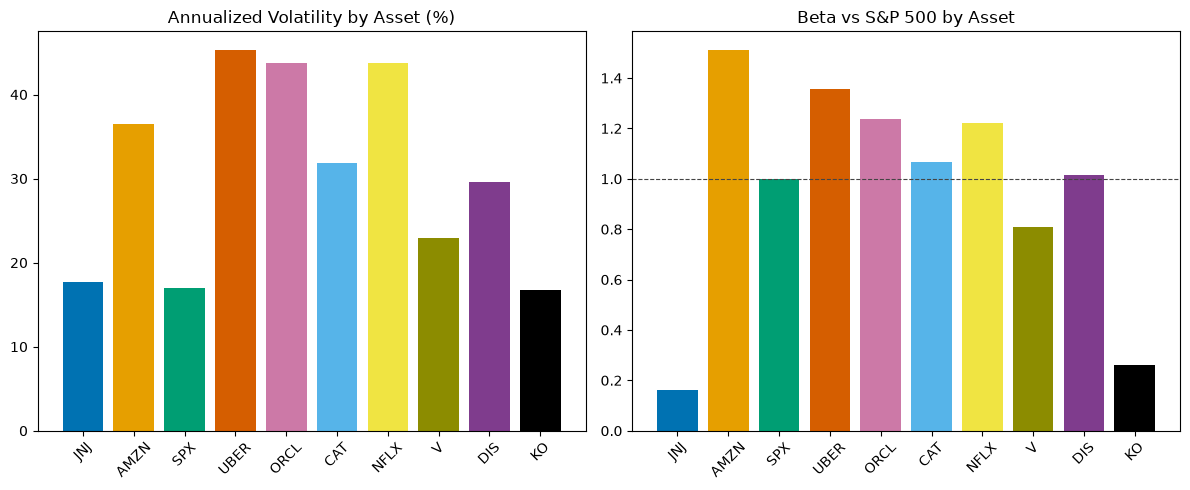

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
rm = risk_metrics[risk_metrics['Ticker'] != 'PORTFOLIO'].set_index('Ticker').loc[ticker_order]
bar_colors = [color_map[t] for t in rm.index]
axes[0].bar(rm.index, rm['Ann_Volatility'] * 100, color=bar_colors)
axes[0].set_title('Annualized Volatility by Asset (%)'); axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(rm.index, rm['Beta'], color=bar_colors)
axes[1].axhline(1.0, color='#444444', linewidth=0.8, linestyle='--')
axes[1].set_title('Beta vs S&P 500 by Asset'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

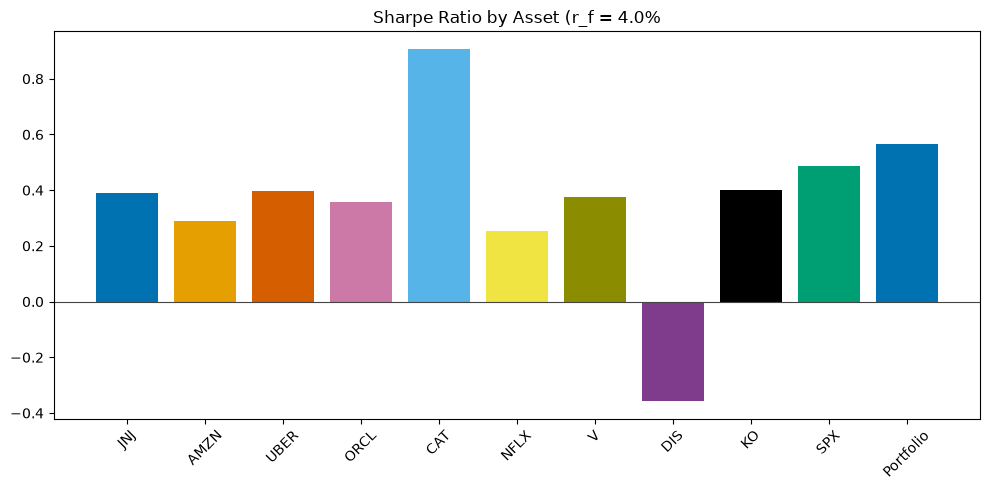

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
rm2 = risk_metrics.set_index('Ticker').loc[portfolio_tickers + ['SPX', 'Portfolio']]
ax.bar(rm2.index, rm2['Sharpe'], color=[color_map.get(t, '#0072B2') for t in rm2.index])
ax.axhline(0, color='#444444', linewidth=0.8)
ax.set_title(f'Sharpe Ratio by Asset (r_f = {RF_ANNUAL*100:.1f}%'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

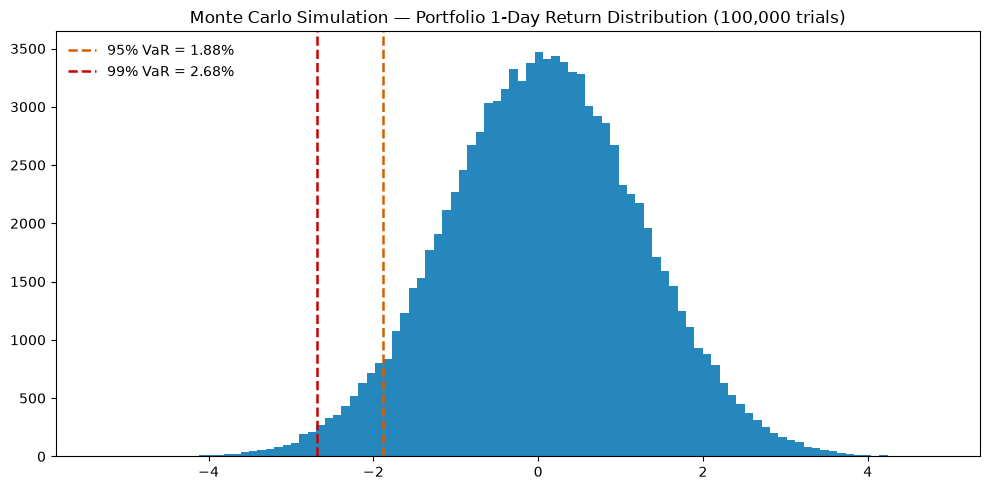

In [14]:
sims = sim_cache['PORTFOLIO']
var95 = -np.percentile(sims, 5); var99 = -np.percentile(sims, 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sims * 100, bins=100, color='#0072B2', alpha=0.85)
ax.axvline(-var95*100, color='#D55E00', linewidth=1.8, linestyle='--', label=f'95% VaR = {var95*100:.2f}%')
ax.axvline(-var99*100, color='#CC0000', linewidth=1.8, linestyle='--', label=f'99% VaR = {var99*100:.2f}%')
ax.set_title(f'Monte Carlo Simulation — Portfolio 1-Day Return Distribution ({N_SIM:,} trials)')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout(); plt.show()

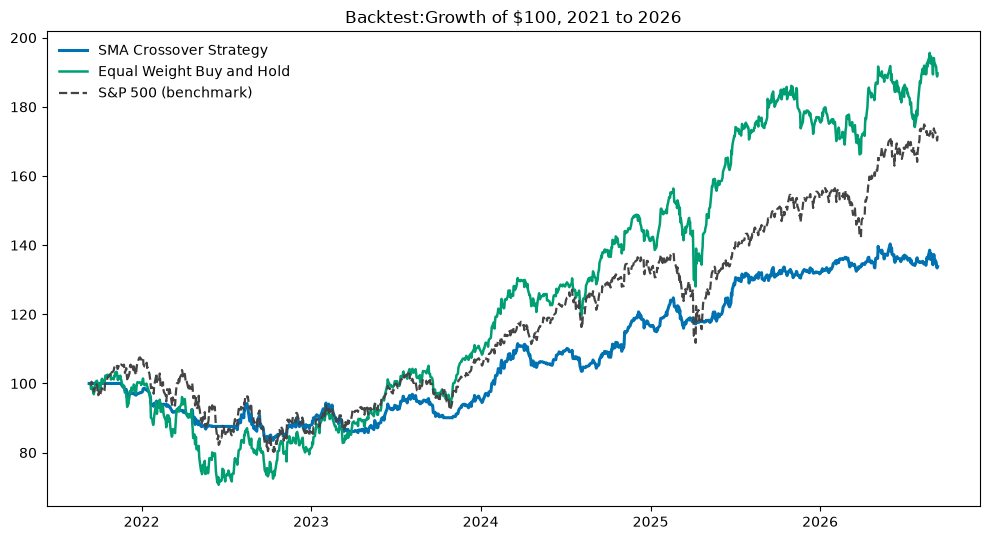

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(cum_strat.index, cum_strat.values, label='SMA Crossover Strategy', color='#0072B2', linewidth=2.2)
ax.plot(cum_bh.index, cum_bh.values, label='Equal Weight Buy and Hold', color='#009E73', linewidth=1.8)
ax.plot(cum_spx.index, cum_spx.values, label='S&P 500 (benchmark)', color='#444444', linewidth=1.6, linestyle='--')
ax.set_title('Backtest:Growth of $100, 2021 to 2026')
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', frameon=False)
plt.tight_layout(); plt.show()

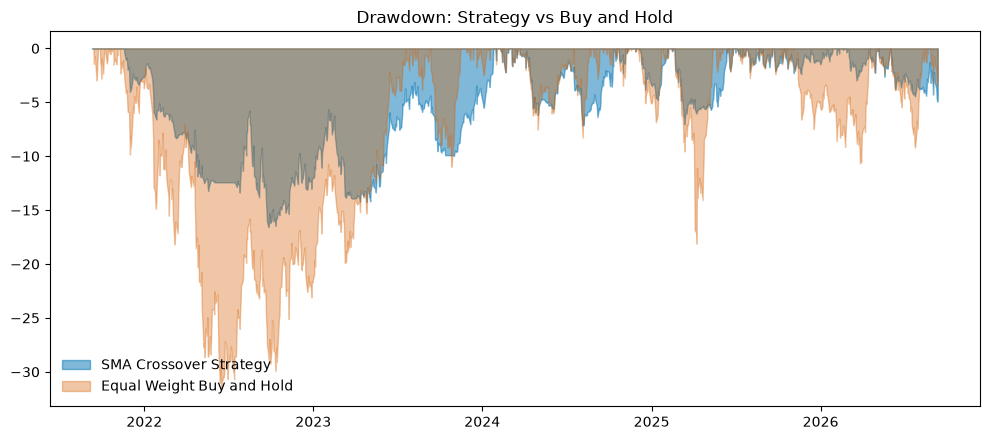

In [16]:
dd_strat =cum_strat / cum_strat.cummax() - 1
dd_bh = cum_bh / cum_bh.cummax() - 1
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(dd_strat.index, dd_strat.values*100, 0, color='#0072B2', alpha=0.5, label='SMA Crossover Strategy')
ax.fill_between(dd_bh.index, dd_bh.values*100, 0, color='#D55E00', alpha=0.35, label='Equal Weight Buy and Hold')
ax.set_title('Drawdown: Strategy vs Buy and Hold')
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='lower left', frameon=False)
plt.tight_layout(); plt.show()

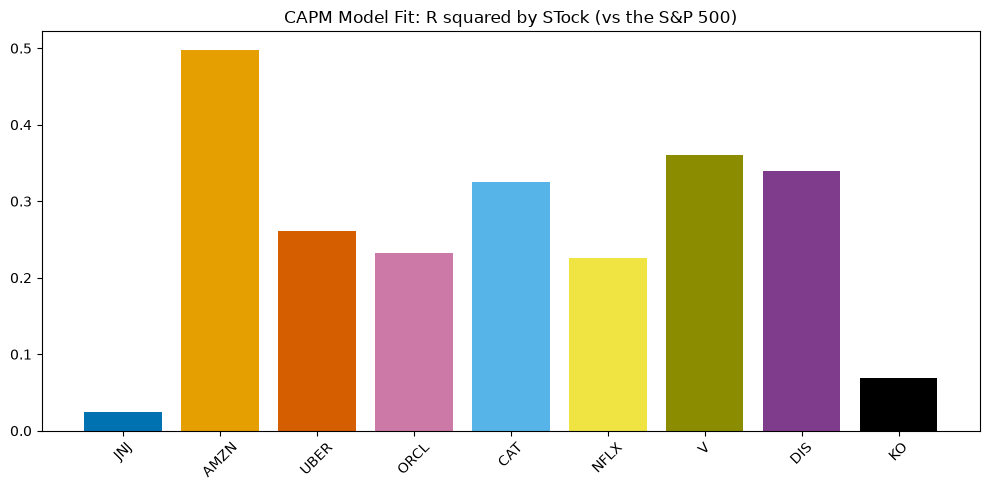

In [17]:
fig, ax = plt.subplots(figsize=(10,5))
gof_sorted = gof_table.set_index('Ticker').loc[portfolio_tickers]
ax.bar(gof_sorted.index, gof_sorted['R_squared'], color=[color_map[t] for t in gof_sorted.index])
ax.set_title('CAPM Model Fit: R squared by STock (vs the S&P 500)'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

CAT and AMZN combine strong returns with the best fitting market models. DIS is the clearest case where the SMA overlay adds real value. The portfolio's Monte Carlo VAR is small enough for a moderate to growth client to comfortably hold. 

The recommensation for the capital analyist would be to keep the 9 stock equal weight universe, apply the SMA crossover overlay selectively to the high beta growth sleeve for drawdown control, hold the defensive sleeve as  buy and hold, and monitor the Monte Carlo VAR monthly as position sizes drifts. 